In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
rnn_model = models.Sequential()

rnn_model.add(layers.Embedding(vocab_size, 128, input_length=max_len))
rnn_model.add(layers.SimpleRNN(64))
rnn_model.add(layers.Dense(32, activation='relu'))
rnn_model.add(layers.Dense(1, activation='sigmoid'))

rnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.7054 - loss: 0.5425 - val_accuracy: 0.8342 - val_loss: 0.3904
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 95ms/step - accuracy: 0.7792 - loss: 0.4735 - val_accuracy: 0.6681 - val_loss: 0.6587
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 96ms/step - accuracy: 0.8588 - loss: 0.3327 - val_accuracy: 0.7442 - val_loss: 0.5207


In [ ]:
lstm_model = models.Sequential()
lstm_model.add(layers.Embedding(vocab_size, 128))
lstm_model.add(layers.LSTM(64))
lstm_model.add(layers.Dense(32, activation='relu'))
lstm_model.add(layers.Dense(1, activation='sigmoid'))

lstm_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

lstm_history = lstm_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 129s 318ms/step - accuracy: 0.7982 - loss: 0.4285 - val_accuracy: 0.8672 - val_loss: 0.3182
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 123s 269ms/step - accuracy: 0.9062 - loss: 0.2339 - val_accuracy: 0.8730 - val_loss: 0.3224
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 143s 271ms/step - accuracy: 0.9360 - loss: 0.1705 - val_accuracy: 0.8725 - val_loss: 0.3247


In [ ]:
gru_model = models.Sequential()
gru_model.add(layers.Embedding(vocab_size, 128))
gru_model.add(layers.GRU(64))
gru_model.add(layers.Dense(32, activation='relu'))
gru_model.add(layers.Dense(1, activation='sigmoid'))

gru_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

gru_history = gru_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 116s 288ms/step - accuracy: 0.7830 - loss: 0.4424 - val_accuracy: 0.8457 - val_loss: 0.3709
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 113s 288ms/step - accuracy: 0.9032 - loss: 0.2446 - val_accuracy: 0.8799 - val_loss: 0.3013
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 113s 289ms/step - accuracy: 0.9388 - loss: 0.1630 - val_accuracy: 0.8724 - val_loss: 0.3268


782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7442 - loss: 0.5207
RNN Test Accuracy: 0.744159996509552
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8725 - loss: 0.3247
LSTM Test Accuracy: 0.8725200295448303
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.8724 - loss: 0.3268
GRU Test Accuracy: 0.872439980506897


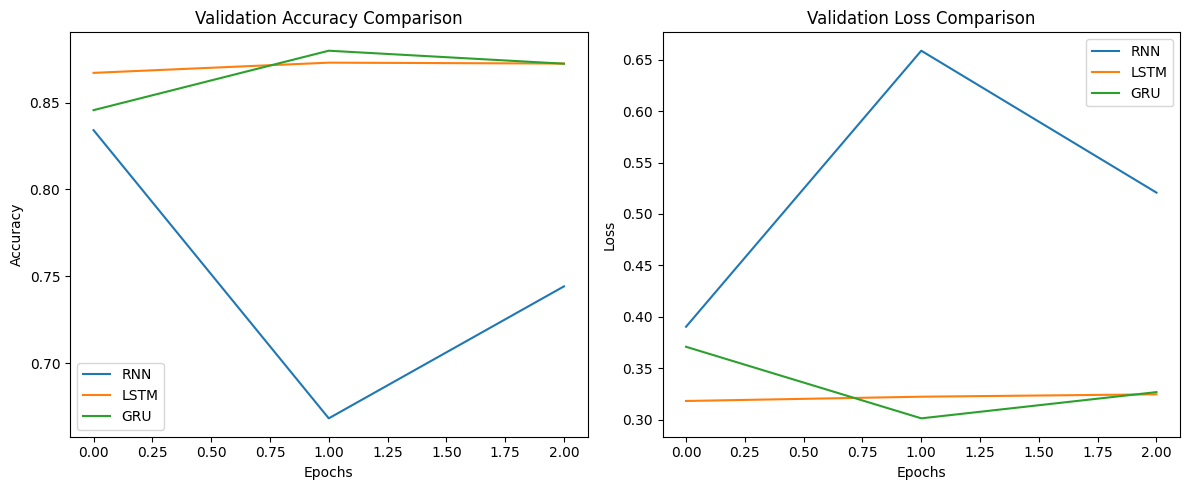

In [ ]:
rnn_loss, rnn_acc = rnn_model.evaluate(x_test, y_test)
print("RNN Test Accuracy:", rnn_acc)

lstm_loss, lstm_acc = lstm_model.evaluate(x_test, y_test)
print("LSTM Test Accuracy:", lstm_acc)

gru_loss, gru_acc = gru_model.evaluate(x_test, y_test)
print("GRU Test Accuracy:", gru_acc)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(gru_history.history['val_accuracy'], label='GRU')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(rnn_history.history['val_loss'], label='RNN')
plt.plot(lstm_history.history['val_loss'], label='LSTM')
plt.plot(gru_history.history['val_loss'], label='GRU')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()